<a href="https://colab.research.google.com/github/hamzaghoudrani/TP1/blob/main/Tp3_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 3: CNN — Convolution and Pooling

## Introduction

A **convolution** is a fundamental operation in Convolutional Neural Networks (CNNs).
It consists of sliding a filter (weight matrix) over an image to extract
important features such as edges, lines, and shapes.

### How it works:
- We scan each pixel of the image
- We multiply the neighboring pixel values by the filter weights
- We compute a new value for that pixel

### In this TP, we will:
1. Manually apply a convolution on a grayscale image
2. Visualize the effect of different filters
3. Understand and implement **Max Pooling**

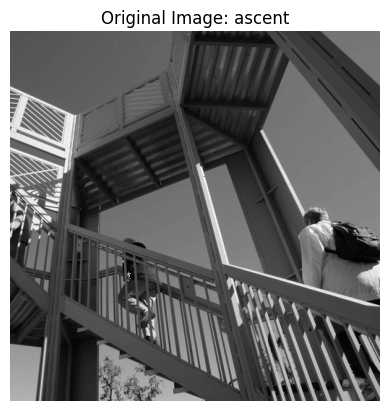

Image dimensions: (512, 512)


In [ ]:
import cv2
import numpy as np
from scipy import datasets
import matplotlib.pyplot as plt

# Load the ascent image
i = datasets.ascent()

# Display the original image
plt.gray()
plt.grid(False)
plt.axis('off')
plt.title("Original Image: ascent")
plt.imshow(i)
plt.show()

print(f"Image dimensions: {i.shape}")

## Step 2: Creating the Convolution Filter

Before applying the filter, we create a **copy of the original image**
that will store the transformed pixel values.

We then define a 3x3 filter. Each filter highlights a different type of feature:

| Filter | Effect |
|--------|--------|
| `[[0,1,0],[1,-4,1],[0,1,0]]` | Edge detection (Laplacian) |
| `[[-1,-2,-1],[0,0,0],[1,2,1]]` | Horizontal lines (Sobel horizontal) |
| `[[-1,0,1],[-2,0,2],[-1,0,1]]` | Vertical lines (Sobel vertical) |

The `weight` parameter controls how strongly the filter effect is amplified.

In [ ]:
# Copy the image and convert to int32 to handle negative filter values
i_transformed = np.copy(i).astype(np.int32)
i = i.astype(np.int32)

size_x = i_transformed.shape[0]
size_y = i_transformed.shape[1]

print(f"Image size: {size_x} x {size_y}")
print(f"Image dtype: {i.dtype}")               # should print int32

# Define the convolution filter (edge detection - Laplacian)
filter = [[0,  1,  0],
          [1, -4,  1],
          [0,  1,  0]]

# Other filters to try:
# filter = [[-1, -2, -1], [0, 0, 0], [1, 2, 1]]   # horizontal lines
# filter = [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]   # vertical lines

weight = 1

Image size: 512 x 512
Image dtype: int32


## Step 3: Applying the Convolution and Displaying the Result

We iterate over every pixel of the image (leaving a 1-pixel border on all sides).
For each pixel, we compute the **element-wise product** between its 3x3 neighborhood
and the filter, then sum all the results.

### Important points:
- We multiply the result by `weight` to control the filter intensity
- We **clip** the value between 0 and 255 to stay within valid pixel range
- The result is stored in `i_transformed`

### Expected observation:
Applying the **vertical Sobel filter** `[[-1,0,1],[-2,0,2],[-1,0,1]]`
clearly highlights the **vertical lines** of the staircase image.

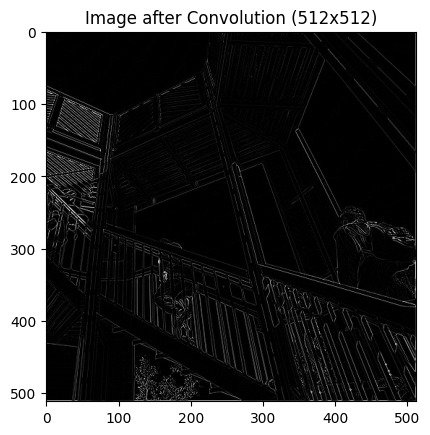

In [ ]:
# Apply the convolution pixel by pixel
for x in range(1, size_x - 1):
    for y in range(1, size_y - 1):
        output = 0.0

        # Top row of filter
        output += i[x-1, y-1] * filter[0][0]
        output += i[x,   y-1] * filter[0][1]
        output += i[x+1, y-1] * filter[0][2]

        # Middle row of filter
        output += i[x-1, y  ] * filter[1][0]
        output += i[x,   y  ] * filter[1][1]
        output += i[x+1, y  ] * filter[1][2]

        # Bottom row of filter
        output += i[x-1, y+1] * filter[2][0]
        output += i[x,   y+1] * filter[2][1]
        output += i[x+1, y+1] * filter[2][2]

        output = output * weight

        # Clip between 0 and 255
        if output < 0:
            output = 0
        if output > 255:
            output = 255

        i_transformed[x, y] = output

# Display the image after convolution
plt.gray()
plt.grid(False)
plt.title("Image after Convolution (512x512)")
plt.imshow(i_transformed)
plt.show()

## Step 4: Understanding Max Pooling

After convolution, we obtain a **feature map** that highlights specific patterns.
**Max Pooling** reduces the size of this feature map while keeping
the most important detected features.

### How Max Pooling (2x2) works:
1. Divide the image into 2x2 pixel blocks
2. Keep only the **maximum value** from each block
3. The resulting image has **4 times fewer pixels**
   (half the width × half the height)

### Advantages of Max Pooling:
- Reduces computational cost for the next layers
- Makes the model more robust to small translations
- Preserves the strongest features (edges, high intensities)

### In our case:
512 x 512 pixels → **256 x 256 pixels**

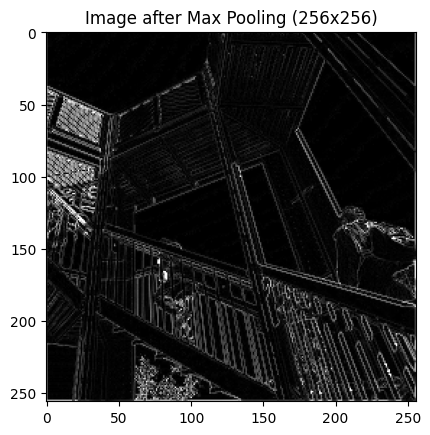

New image size after pooling: (256, 256)


In [ ]:
# Dimensions of the new image (half the original)
new_x = int(size_x / 2)
new_y = int(size_y / 2)
newImage = np.zeros((new_x, new_y))

# Apply Max Pooling (2x2)
for x in range(0, size_x, 2):
    for y in range(0, size_y, 2):
        pixels = []
        pixels.append(i_transformed[x,   y  ])
        pixels.append(i_transformed[x+1, y  ])
        pixels.append(i_transformed[x,   y+1])
        pixels.append(i_transformed[x+1, y+1])

        pixels.sort(reverse=True)
        newImage[int(x/2), int(y/2)] = pixels[0]  # keep the max value

# Display the image after pooling
plt.gray()
plt.grid(False)
plt.title("Image after Max Pooling (256x256)")
plt.imshow(newImage)
plt.show()

print(f"New image size after pooling: {newImage.shape}")

## Conclusion

In this TP, we implemented from scratch the two core operations of a CNN:

| Operation | Role | Effect on size |
|-----------|------|----------------|
| **Convolution** | Extract features (edges, lines) | Unchanged (with border margin) |
| **Max Pooling** | Reduce size while keeping key features | Divided by 4 (2x2 pool) |

### Key observations:
- The **Laplacian filter** `[[0,1,0],[1,-4,1],[0,1,0]]` detects all edges uniformly
- The **vertical Sobel filter** `[[-1,0,1],[-2,0,2],[-1,0,1]]` strongly highlights vertical lines
- After pooling, the image is 4x smaller but the detected features remain clearly visible

### Why does this matter?
In a real CNN (like VGG or ResNet), dozens of these convolution + pooling
layers are stacked on top of each other. Each layer extracts increasingly
complex features — from simple edges to full object shapes.